In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from src import soporte_correlacion as sp_corr

In [5]:
pd.set_option("display.max_columns",None) #display todas las columnas
df_hr = pd.read_csv("hr_final.csv",index_col=0)

df_hr.head()

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income
0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,single,8,yes,11,3,1,0,8,0,1,6,4,0,5.0,41,4,5993.0
1,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,married,1,no,23,4,4,1,10,3,3,10,7,1,7.0,49,2,5130.0
2,yes,travel_rarely,research & development,2,2,other,4,4,male,2,1,laboratory technician,single,6,yes,15,3,2,0,7,3,3,0,0,0,0.0,37,3,2090.0
3,no,travel_frequently,research & development,3,4,life sciences,5,4,female,3,1,research scientist,married,1,yes,11,3,3,0,8,3,3,8,7,3,0.0,33,3,2909.0
4,no,travel_rarely,research & development,2,1,medical,7,1,male,3,1,laboratory technician,married,9,no,12,3,4,1,6,3,3,2,2,2,2.0,27,2,3468.0


In [6]:
df_hr.columns

Index(['attrition', 'business_travel', 'department', 'distance_from_home',
       'education', 'education_field', 'employee_number',
       'environment_satisfaction', 'gender', 'job_involvement', 'job_level',
       'job_role', 'marital_status', 'num_companies_worked', 'over_time',
       'percent_salary_hike', 'performance_rating',
       'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager', 'age',
       'job_satisfaction', 'monthly_income'],
      dtype='str')

### **<font color="red">¿Existe una brecha salarial entre los empleados que se quedan y los que se van?</font>**
      - Herramienta: sns.boxplot(x='attrition', y='monthly_income', data=df)

In [7]:
df_hr['salary_cat'] = pd.cut(df_hr['monthly_income'], bins=[0,5000,10000,20000], labels=['bajo','medio','alto'])

In [8]:
crosstab_salary= pd.crosstab(df_hr['salary_cat'], df_hr['attrition'], normalize= 'columns')
print(crosstab_salary)

attrition         no       yes
salary_cat                    
bajo        0.473301  0.689076
medio       0.319579  0.210084
alto        0.207120  0.100840


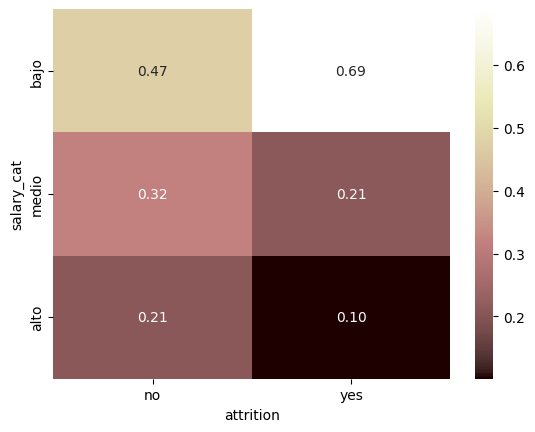

In [9]:
sns.heatmap(crosstab_salary, annot=True, cmap='pink', fmt='.2f');

la mayoria de los que se van son los que tienen el salario más bajo.

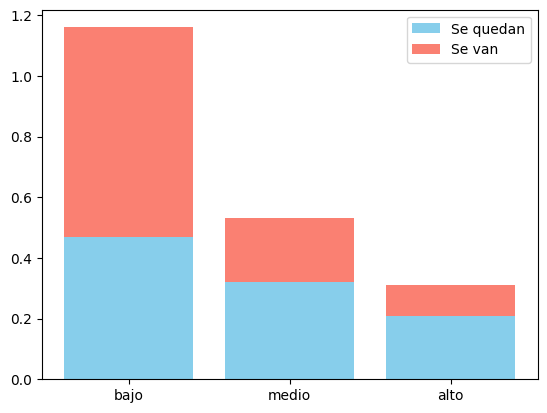

In [20]:
niveles = ['bajo', 'medio', 'alto']
se_quedan = [0.47, 0.32, 0.21]
se_van = [0.69, 0.21, 0.10]
 
fig, ax = plt.subplots()
 
# 1. Dibujamos la base (se quedan)
ax.bar(niveles, se_quedan, label='Se quedan', color='skyblue')
 
# 2. CLAVE: Usamos 'bottom' para apilar
# Esto le dice que el "suelo" de la barra roja es el valor de la azul
ax.bar(niveles, se_van, bottom=se_quedan, label='Se van', color='salmon')
 
ax.legend()
plt.show()



In [ ]:

ax.bar(niveles, se_quedan, label='Se quedan', color='skyblue')
ax.bar(niveles, se_van, bottom=se_quedan, label='Se van', color='salmon')
ax.legend()
 plt.show()

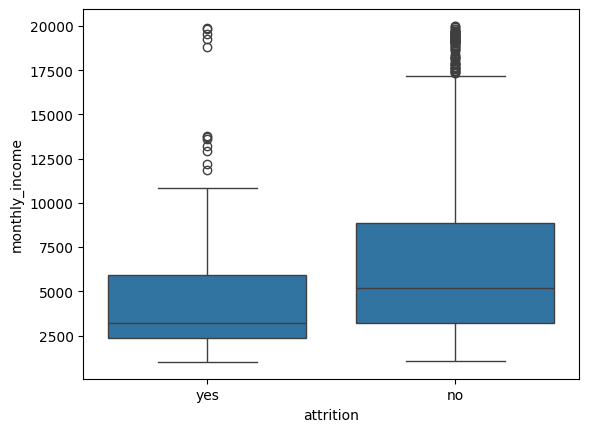

In [ ]:
sns.boxplot(data=df_hr,x="attrition", y="monthly_income");

Existe una brecha salarial entre los empleados que se quedan y los que se van : < monthly_income = > attrition vs  >monthly_income = < attrition. 
Notamos que la mediana del salario de los que se van, es igual al 25% del salario mínimo de los que se quedan.

### **<font color="red">¿El trabajo extra (Overtime) es un detonante para la rotación? </font>**
       - Herramienta: sns.countplot(x='over_time', hue='attrition', data=df)

In [ ]:
crosstab = pd.crosstab(df_hr['over_time'], df_hr['attrition'], normalize= 'columns')
print(crosstab)

attrition        no      yes
over_time                   
no         0.773463  0.47479
yes        0.226537  0.52521


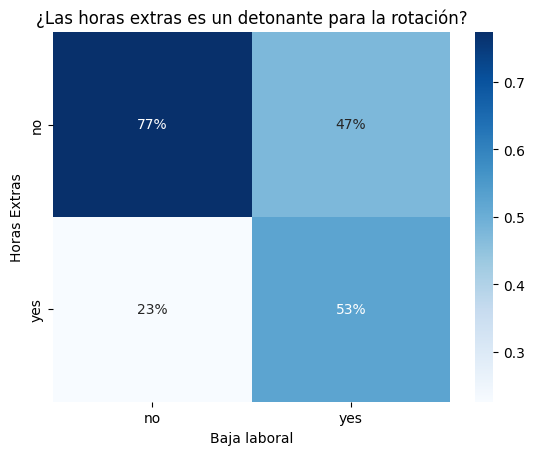

In [ ]:
sns.heatmap(crosstab, annot=True, cmap='Blues', fmt='.0%')
plt.title('¿Las horas extras es un detonante para la rotación?', fontsize=12)
plt.xlabel('Baja laboral')
plt.ylabel('Horas Extras')

plt.show()


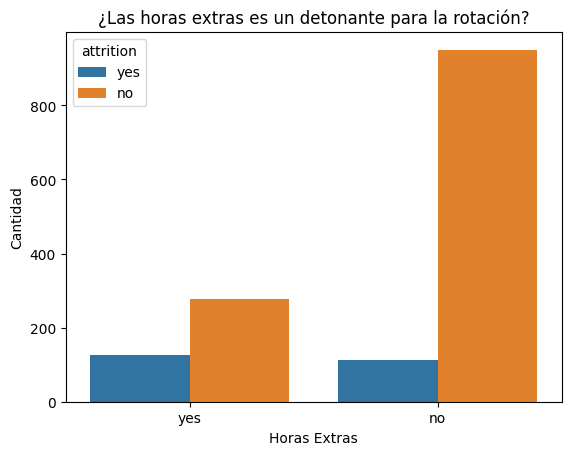

In [ ]:
sns.countplot(x='over_time', hue='attrition',data=df_hr)
plt.title('¿Las horas extras es un detonante para la rotación?', fontsize=12)
plt.xlabel('Horas Extras')
plt.ylabel('Cantidad')

plt.show()


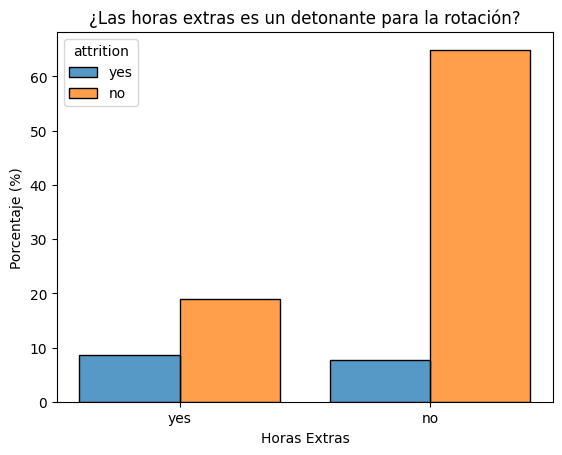

In [ ]:
sns.histplot(x='over_time', hue='attrition', data=df_hr, 
             multiple='dodge', shrink=0.8, stat='percent')

plt.title('¿Las horas extras es un detonante para la rotación?', fontsize=12)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Horas Extras')
plt.show()

### **<font color="red">¿Influye la distancia al hogar en la decisión de abandonar la empresa? </font>**
       - Herramienta: sns.kdeplot comparando distance_from_home para ambos grupos de attrition.

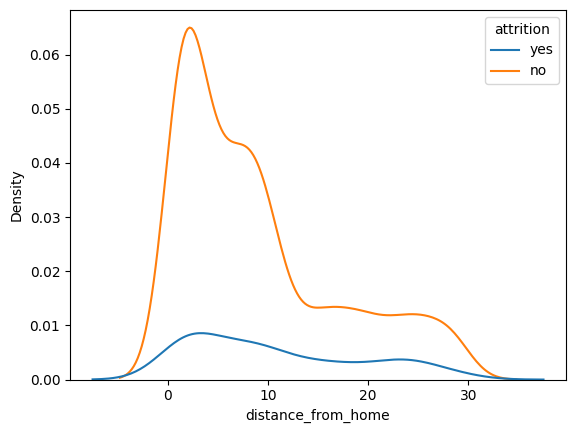

In [ ]:
sns.kdeplot(data=df_hr, x="distance_from_home", hue="attrition");
#dibuja la estimación de densidad kernel de `distance_from_home` para cada valor de `attrition`, comparando la distribución de distancias entre los que se quedan y los que se van.

In [ ]:
df_hr['distance_cat']= pd.cut(df_hr['distance_from_home'], bins=[0,10,20,30], labels=['Cerca','Medio','Lejos'])

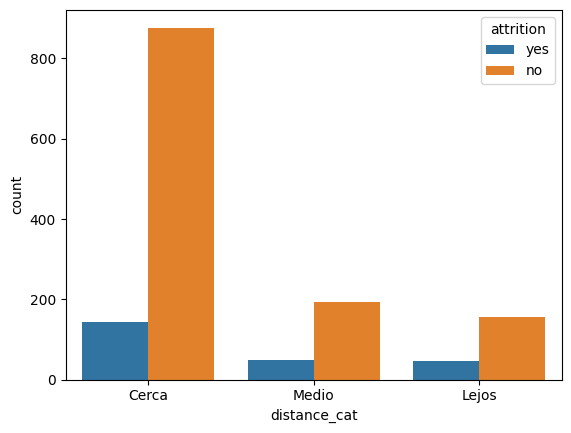

In [ ]:
sns.countplot(x='distance_cat', hue='attrition',data=df_hr);

In [ ]:
crosstabDisCount = pd.crosstab(df_hr['distance_cat'], df_hr['attrition'], normalize= 'columns')

In [ ]:
crosstabDisCount

attrition,no,yes
distance_cat,,
Cerca,0.715334,0.603376
Medio,0.157423,0.202532
Lejos,0.127243,0.194093


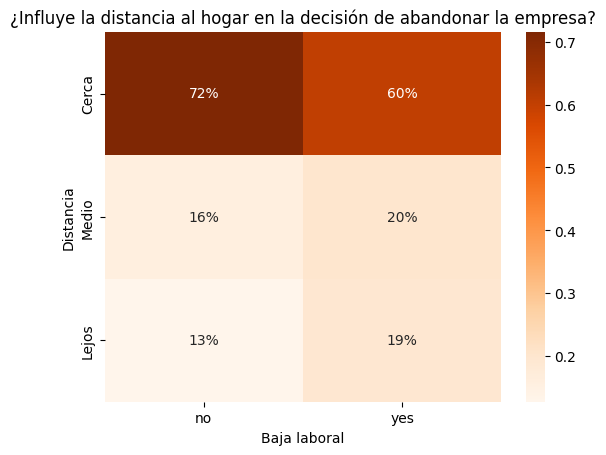

In [ ]:
sns.heatmap(crosstabDisCount, annot=True, fmt='.0%',cmap='Oranges')
plt.title('¿Influye la distancia al hogar en la decisión de abandonar la empresa?', fontsize=12)
plt.xlabel('Baja laboral')
plt.ylabel('Distancia')

plt.show()



el 40% de los que se van, viven entre medio y lejos de la empresa

### **<font color="red"> ¿Qué departamentos o roles tienen la tasa de rotación más alta?</font>**
    - Herramienta: Gráfico de barras apiladas o sns.countplot con job_role o department.

<Axes: xlabel='attrition', ylabel='count'>

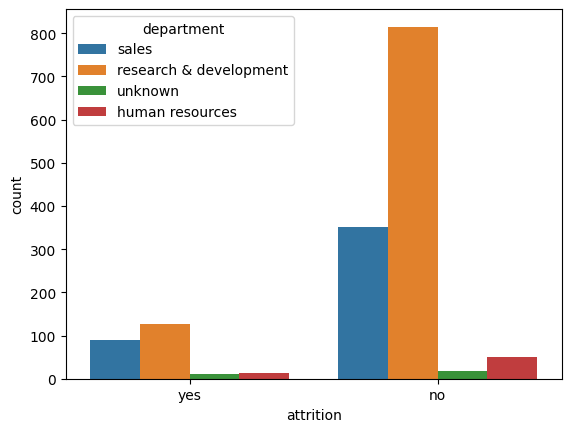

In [ ]:
sns.countplot(data=df_hr, x="attrition", hue="department")

In [ ]:
df_hr['job_level_cat']= pd.cut(df_hr['job_level'], bins=[1,2,3,4,5], labels=['junior','semi-senior','senior','expert'])

In [ ]:
pd.crosstab(df_hr['job_level_cat'], df_hr['department'], normalize= 'columns').round(2)

department,human resources,research & development,sales,unknown
job_level_cat,,,,
junior,0.43,0.53,0.65,0.50
semi-senior,0.20,0.25,0.22,0.22
senior,0.13,0.12,0.09,0.28
expert,0.23,0.09,0.04,0.00


In [ ]:
df_hr.groupby('attrition')['department'].value_counts(normalize=True).round(2)   

attrition  department            
no         research & development    0.66
           sales                     0.28
           human resources           0.04
           unknown                   0.02
yes        research & development    0.53
           sales                     0.37
           human resources           0.05
           unknown                   0.04
Name: proportion, dtype: float64

<Axes: xlabel='attrition', ylabel='count'>

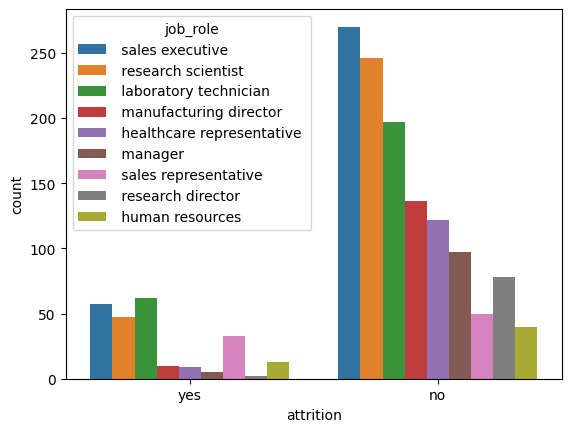

In [ ]:
sns.countplot(data=df_hr, x="attrition", hue="job_role")

In [ ]:
pd.crosstab(df_hr['job_role'], df_hr['attrition'], normalize= 'columns').round(2)

attrition,no,yes
job_role,,
healthcare representative,0.10,0.04
human resources,0.03,0.05
laboratory technician,0.16,0.26
manager,0.08,0.02
manufacturing director,0.11,0.04
research director,0.06,0.01
research scientist,0.20,0.20
sales executive,0.22,0.24
sales representative,0.04,0.14


In [ ]:
# 26% labotatory technician, 20% research scientist, 24% sales executive

In [ ]:
df_hr.groupby('attrition')['department'].value_counts(normalize=True).round(2)   

attrition  department            
no         research & development    0.66
           sales                     0.28
           human resources           0.04
           unknown                   0.02
yes        research & development    0.53
           sales                     0.37
           human resources           0.05
           unknown                   0.04
Name: proportion, dtype: float64

# 2. Análisis de Satisfacción y Clima
  Se centra en las métricas de bienestar (job_satisfaction, environment_satisfaction, work_life_balance).

### **<font color="red"> ¿Cómo se distribuye la satisfacción laboral según el nivel del puesto (job_level)?</font>**
       * Herramienta: sns.violinplot(x='job_level', y='job_satisfaction', data=df)

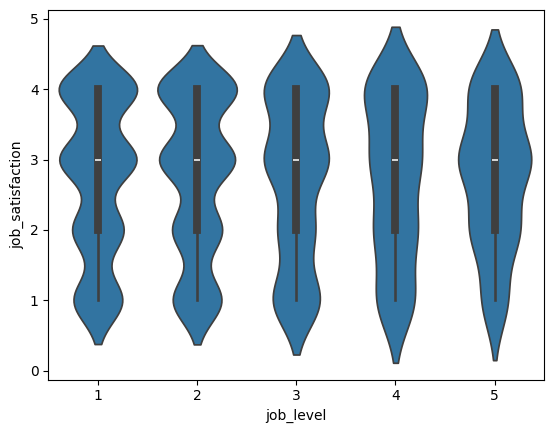

In [ ]:
sns.violinplot(data=df_hr,x="job_level",y="job_satisfaction");

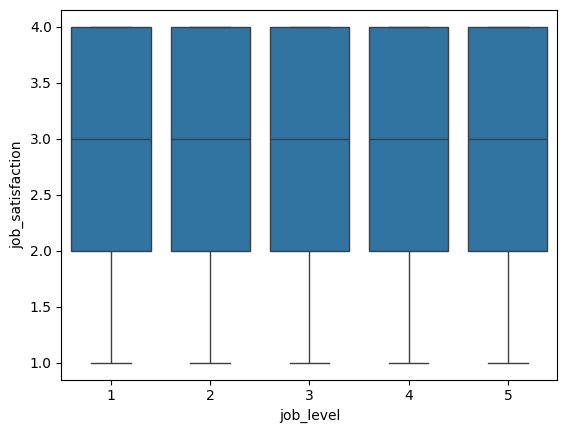

In [ ]:
sns.boxplot(data=df_hr,x="job_level",y="job_satisfaction");

**Yo aqui haría un groupby por job level de la media de satisfaction, para aclarar los datos**

In [ ]:
df_hr.groupby("job_level")["job_satisfaction"].mean()

job_level
1    2.724265
2    2.733209
3    2.689498
4    2.716981
5    2.753623
Name: job_satisfaction, dtype: float64

### **<font color="red"> ¿Existe relación entre el equilibrio vida-trabajo y la satisfacción en el entorno?</font>**
    - Herramienta: Matriz de contingencia (Heatmap) entre work_life_balance y environment_satisfaction.

In [ ]:
tablaconting1 = pd.crosstab(df_hr["work_life_balance"], df_hr["environment_satisfaction"], normalize="index")*100;  #todas las filas suma el 100%, por ej. un 25% no está contento, por otro lado un 31% 4/4
tablaconting1.style.background_gradient(cmap='Blues')


environment_satisfaction,1,2,3,4
work_life_balance,,,,
1,25.000000,16.250000,27.500000,31.250000
2,19.476744,22.674419,29.069767,28.779070
3,18.617614,19.175028,30.992196,31.215162
4,19.607843,16.339869,34.640523,29.411765


In [ ]:
tablaconting2 = pd.crosstab(df_hr["work_life_balance"], df_hr["environment_satisfaction"], normalize="columns")*100;  #todas las columnas suma el 100%, por ejemplo, el 58· odia su entorno con equilibrio al 3.
tablaconting2.style.background_gradient(cmap='Blues')

environment_satisfaction,1,2,3,4
work_life_balance,,,,
1,7.042254,4.513889,4.856512,5.567929
2,23.591549,27.083333,22.075055,22.048998
3,58.802817,59.722222,61.368653,62.360802
4,10.563380,8.680556,11.699779,10.022272


<Axes: xlabel='environment_satisfaction', ylabel='work_life_balance'>

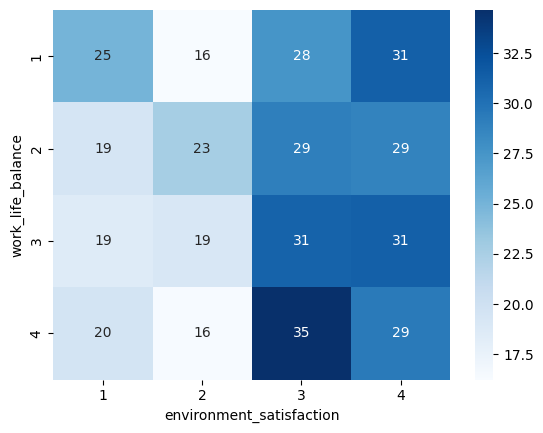

In [ ]:
sns.heatmap(tablaconting1, annot=True, cmap="Blues", cbar=True)


<Axes: xlabel='environment_satisfaction', ylabel='work_life_balance'>

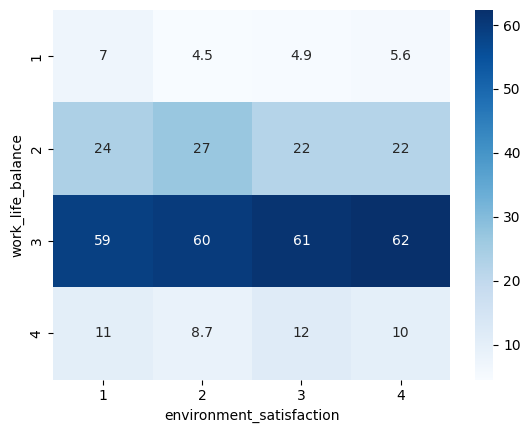

In [ ]:
sns.heatmap(tablaconting2, annot=True, cmap="Blues", cbar=True)

### **<font color="red"> ¿Los empleados con más años bajo el mismo manager tienen mayor satisfacción?</float>**
    - Herramienta: sns.lineplot o sns.barplot comparando years_with_curr_manager con job_satisfaction.

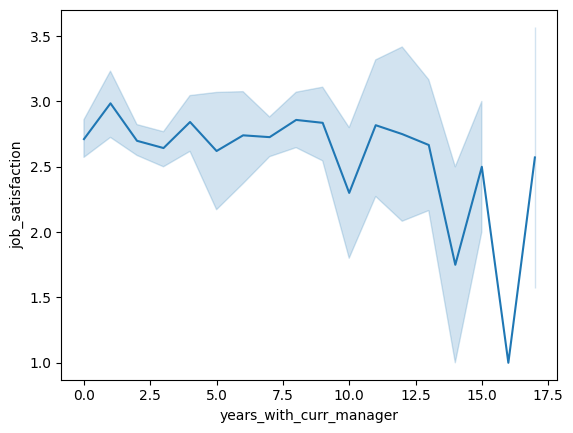

In [ ]:
sns.lineplot(data=df_hr,x="years_with_curr_manager",y="job_satisfaction");

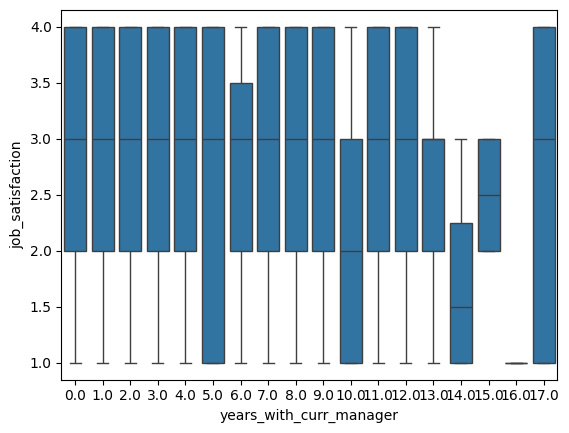

In [ ]:
sns.boxplot(data=df_hr,x="years_with_curr_manager",y="job_satisfaction");

In [ ]:
df_hr["years_bin"] = pd.cut(
    df_hr["years_with_curr_manager"],
    bins=[0,3,6,10,20],
    labels=["0-3","4-6","7-10","10+"]
)

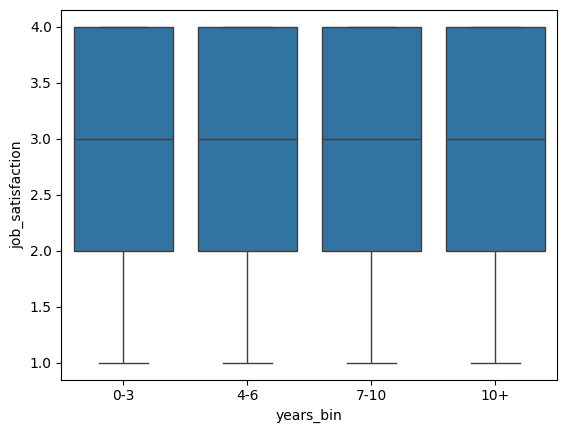

In [ ]:
sns.boxplot(data=df_hr, x="years_bin", y="job_satisfaction");

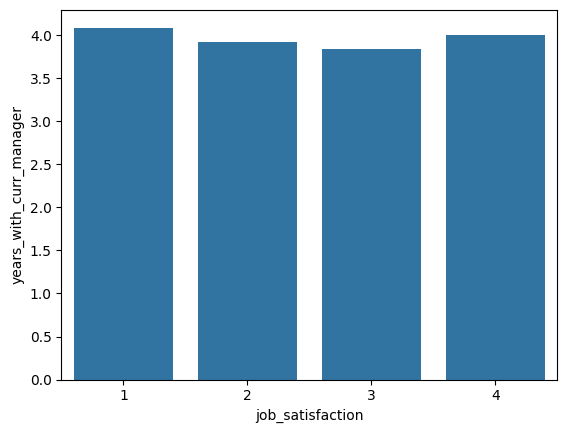

In [ ]:
sns.barplot(data=df_hr,y="years_with_curr_manager",x="job_satisfaction", errorbar=None);

# 3. Correlaciones y Factores Numéricos
  Para identificar qué variables se mueven juntas.

### **<font color="red"> ¿Cuáles son las variables numéricas que más influyen en el ingreso mensual?</font>**
       - Herramienta: Mapa de calor de correlaciones (sns.heatmap(df.corr())) filtrando por monthly_income.

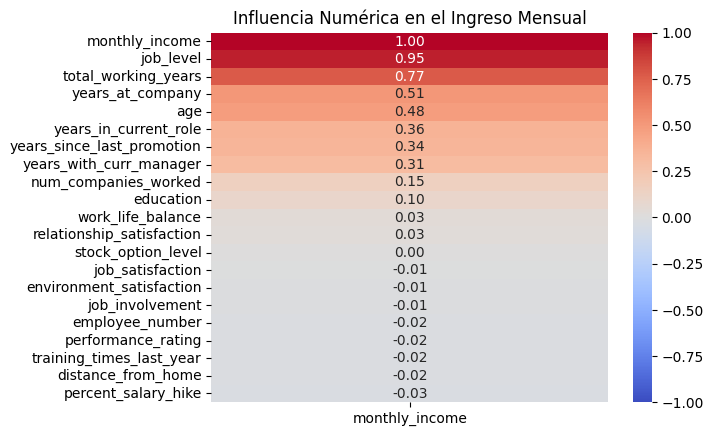

In [ ]:
# Calculamos la matriz de correlación completa (solo numéricas)
corr_matrix = df_hr.corr(numeric_only=True)

# Usamos sort_values para poner las correlaciones más altas arriba
income_corr = corr_matrix[['monthly_income']].sort_values(by='monthly_income', ascending=False)

# 3. Graficamos el Heatmap enfocado
sns.heatmap( income_corr,annot=True,cmap='coolwarm',vmin=-1, vmax=1,fmt=".2f")
# Escala de color: azul (negativo), blanco (cero), rojo (positivo)
# Fija la escala de color de -1 a 1
# Formato de dos decimales

plt.title("Influencia Numérica en el Ingreso Mensual", fontsize=12)
plt.show()

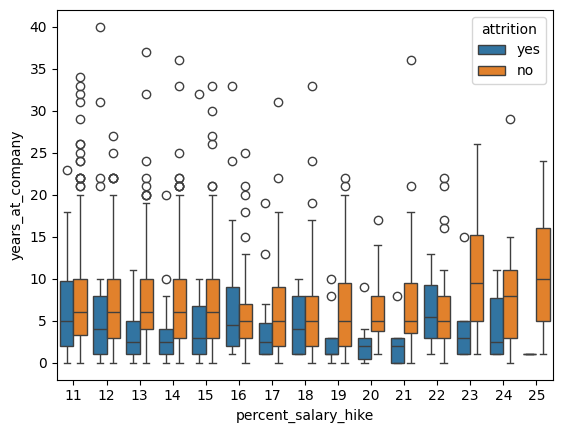

In [ ]:
sns.boxplot(data=df_hr, y="years_at_company", x="percent_salary_hike", hue="attrition");

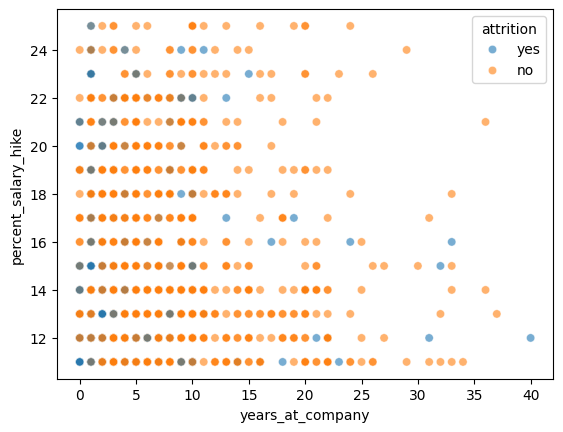

In [ ]:
sns.scatterplot(data=df_hr, x="years_at_company", y="percent_salary_hike", hue="attrition", alpha=0.6);

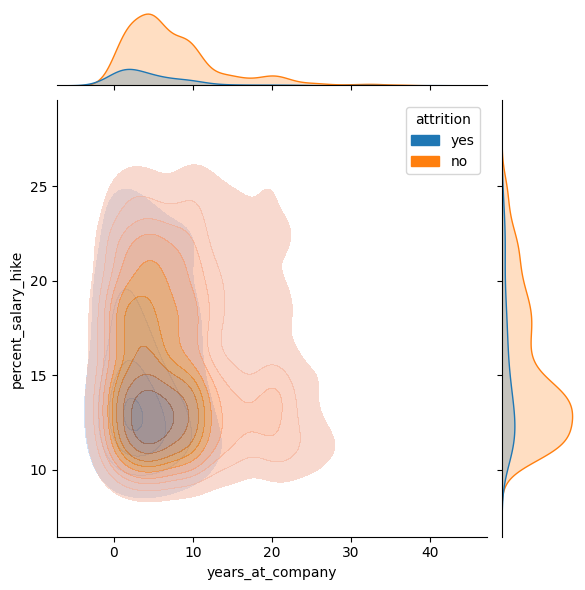

In [ ]:
sns.jointplot(data=df_hr, x="years_at_company", y="percent_salary_hike", hue="attrition", kind="kde", fill=True, alpha=0.5)

### **<font color="red"> ¿Existe una correlación entre el porcentaje de aumento salarial (percent_salary_hike) y el desempeño (performance_rating)?</font>**
       * Herramienta: sns.scatterplot con regresión.

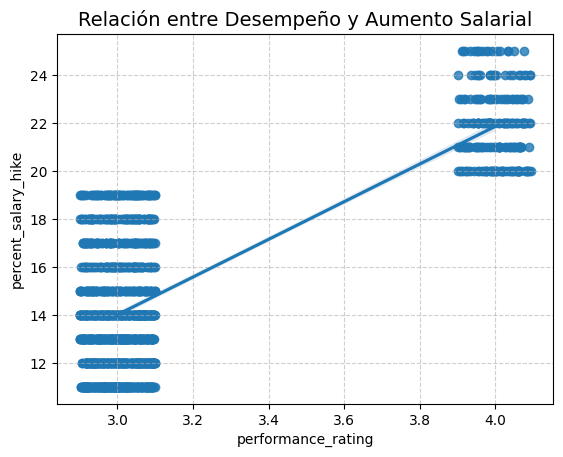

In [ ]:

# regplot añade la línea de tendencia y el "sombreado" (intervalo de confianza)
sns.regplot(data=df_hr,x="performance_rating",y="percent_salary_hike", x_jitter=0.1) # x_jitter Separa un poco los puntos para ver densidad

plt.title("Relación entre Desempeño y Aumento Salarial", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6) # Añade una rejilla para leer mejor
plt.show()

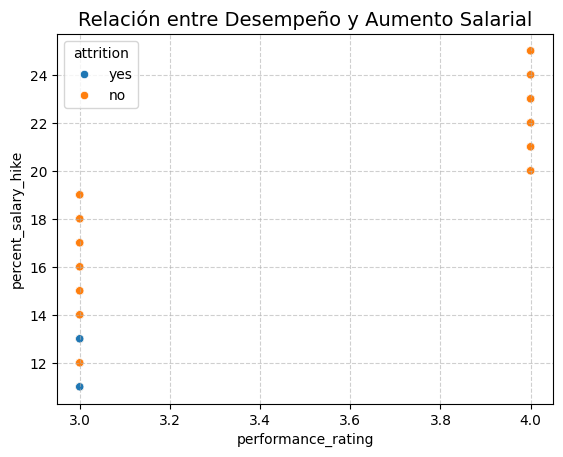

In [ ]:
# regplot añade la línea de tendencia y el "sombreado" (intervalo de confianza)
sns.scatterplot(data=df_hr,x="performance_rating",y="percent_salary_hike", hue= "attrition")

plt.title("Relación entre Desempeño y Aumento Salarial", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6) # Añade una rejilla para leer mejor
plt.show()

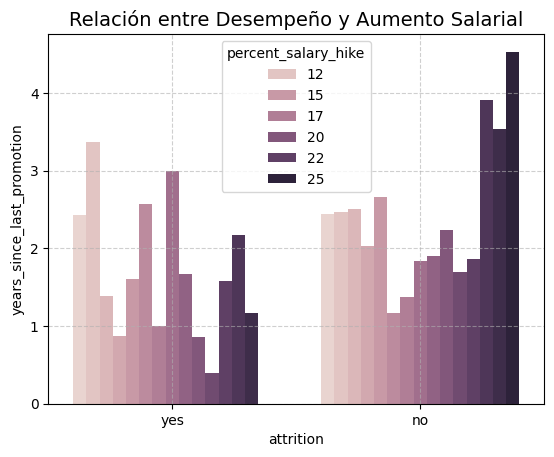

In [ ]:
# regplot añade la línea de tendencia y el "sombreado" (intervalo de confianza)
sns.barplot(data=df_hr,x="attrition",y="years_since_last_promotion", hue= "percent_salary_hike", errorbar=None)

plt.title("Relación entre Desempeño y Aumento Salarial", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6) # Añade una rejilla para leer mejor
plt.show()

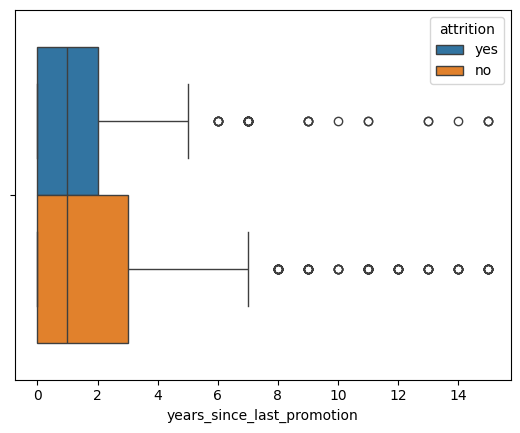

In [ ]:
sns.boxplot(data=df_hr, x="years_since_last_promotion", hue= "attrition");

In [ ]:
df_hr.sample()

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income,salary_cat,distance_cat,job_level_cat,years_bin
651,no,non-travel,sales,2,2,marketing,903,3,female,3,2,sales executive,married,0,yes,22,4,1,1,8,2,3,7,6,7,7.0,47,4,4537.0,bajo,cerca,junior,7-10


### **<font color="red"> ¿Cómo afecta la edad y los años de experiencia al nivel de ingresos?</font>**
    - Herramienta: sns.jointplot para ver la distribución y la relación entre age y total_working_years.

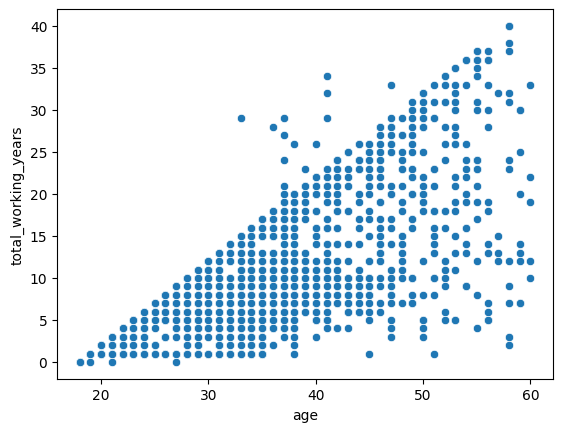

In [ ]:
sns.scatterplot(data=df_hr, x="age",y="total_working_years");

In [ ]:
df_hr = df_hr[df_hr['age'] > df_hr['total_working_years']]

In [ ]:
df_hr = df_hr[(df_hr['age'] - df_hr['total_working_years']) >= 16]

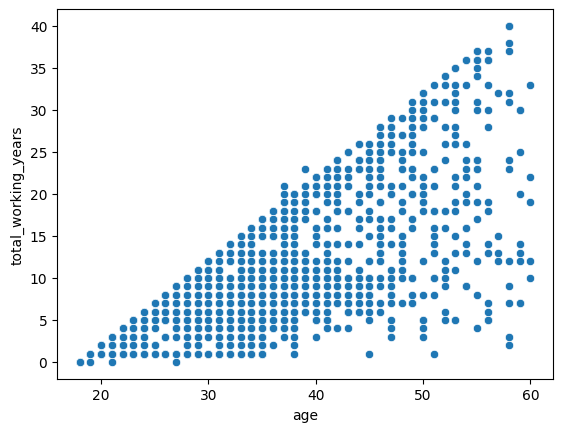

In [ ]:
sns.scatterplot(data=df_hr, x="age",y="total_working_years");

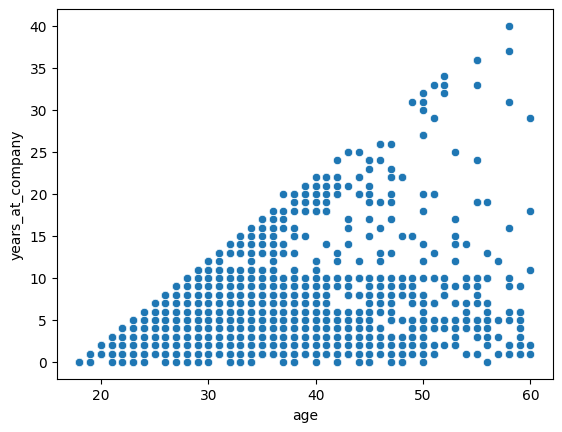

In [ ]:
sns.scatterplot(data=df_hr, x="age",y="years_at_company");

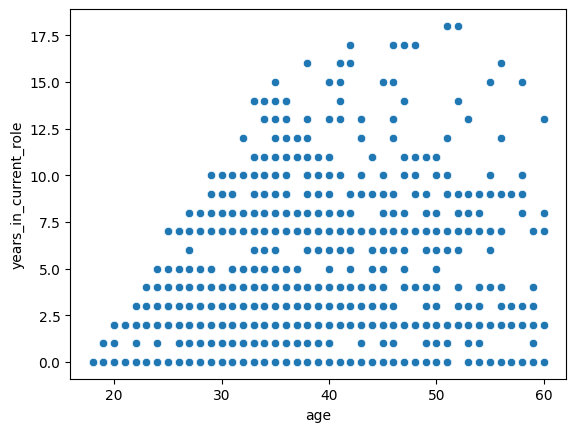

In [ ]:
sns.scatterplot(data=df_hr, x="age",y="years_in_current_role");

In [ ]:
df_hr[(df_hr['total_working_years']>= 25)&(df_hr['age']<=35)] #¡OJO con los datos erróneos!

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income,salary_cat,distance_cat,job_level_cat,years_bin


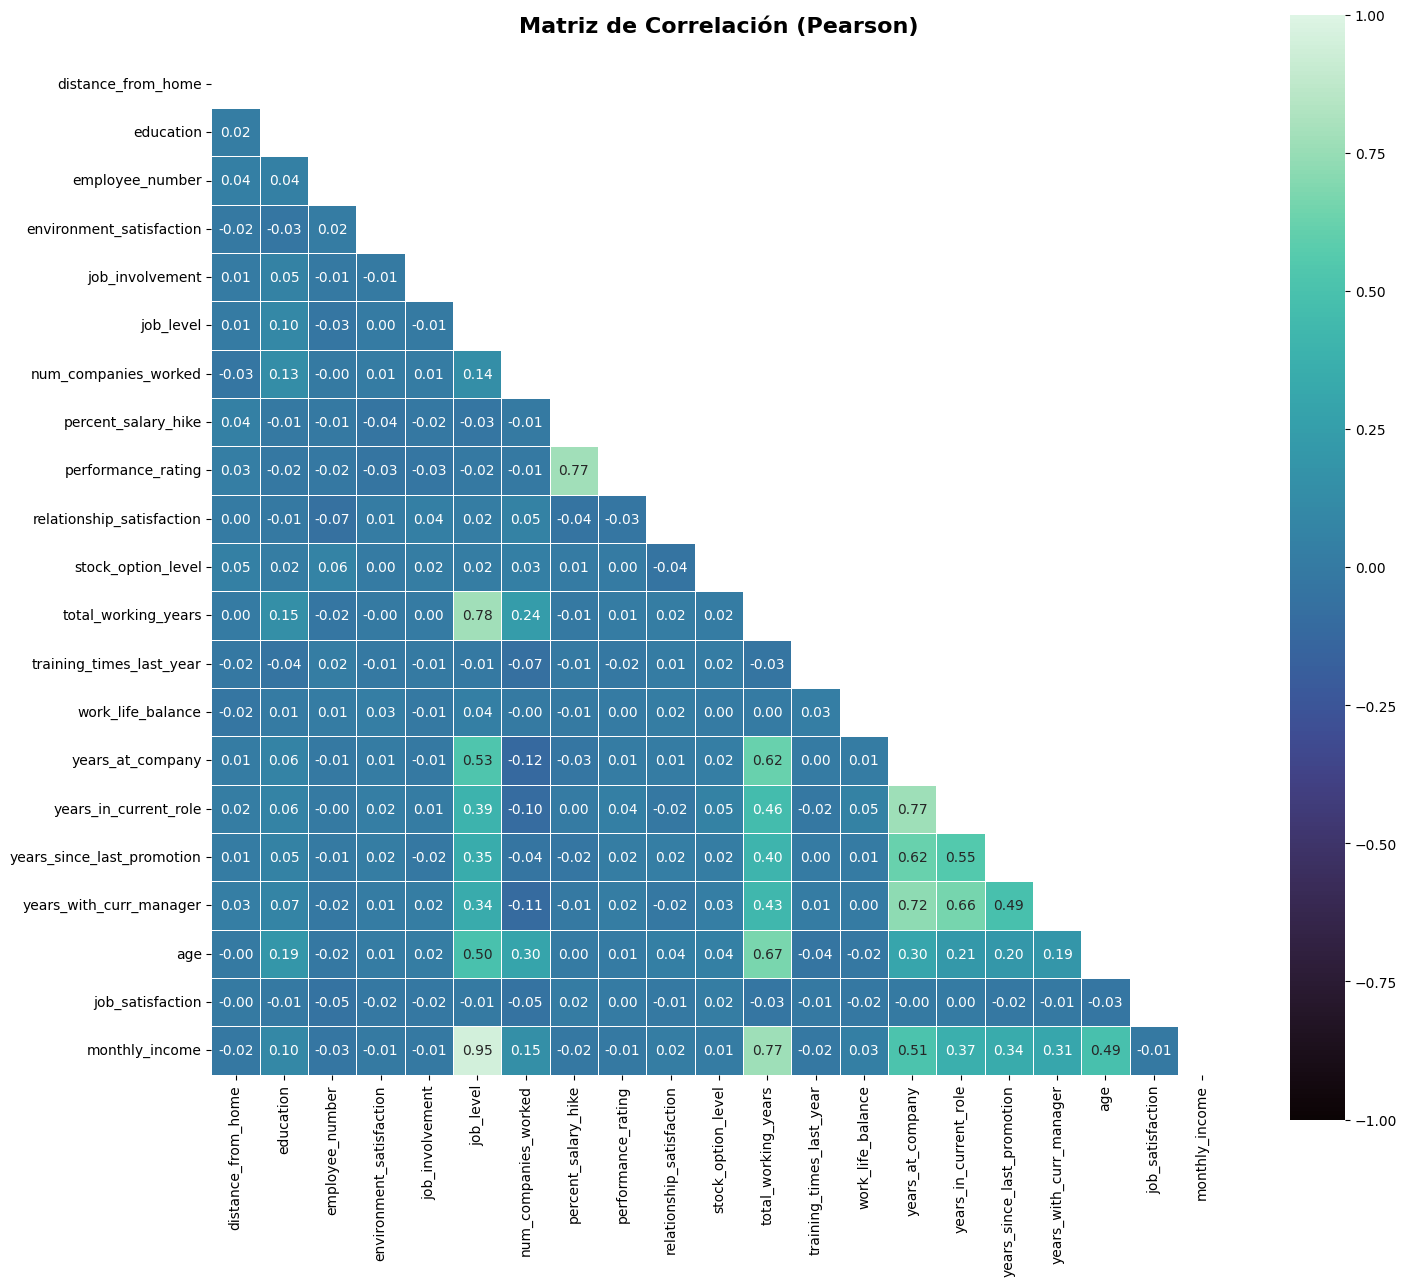

,distance_from_home,education,employee_number,environment_satisfaction,job_involvement,job_level,num_companies_worked,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income
distance_from_home,1.000000,0.017952,0.035255,-0.015000,0.007275,0.006650,-0.031085,0.041187,0.026836,0.003783,0.046640,0.002717,-0.022230,-0.024250,0.012052,0.016391,0.009034,0.025193,-0.001664,-0.004558,-0.016838
education,0.017952,1.000000,0.039864,-0.029191,0.049638,0.100509,0.130896,-0.009656,-0.022720,-0.010961,0.019328,0.145421,-0.041511,0.006827,0.059620,0.060730,0.048123,0.067135,0.192172,-0.011816,0.095597
employee_number,0.035255,0.039864,1.000000,0.015265,-0.009939,-0.027961,-0.001958,-0.011781,-0.018809,-0.067267,0.060248,-0.023686,0.020760,0.012300,-0.013064,-0.003488,-0.006602,-0.018533,-0.016419,-0.049090,-0.025277
environment_satisfaction,-0.015000,-0.029191,0.015265,1.000000,-0.007659,0.002974,0.013301,-0.036785,-0.031283,0.008725,0.001702,-0.001798,-0.009799,0.028295,0.012281,0.024493,0.020187,0.009579,0.009307,-0.020563,-0.007736
job_involvement,0.007275,0.049638,-0.009939,-0.007659,1.000000,-0.007197,0.010588,-0.015932,-0.029955,0.036707,0.021293,0.001988,-0.006280,-0.011159,-0.010505,0.010247,-0.017340,0.021992,0.021088,-0.018199,-0.009020
job_level,0.006650,0.100509,-0.027961,0.002974,-0.007197,1.000000,0.139315,-0.029770,-0.015264,0.017514,0.018527,0.778335,-0.011918,0.038671,0.530384,0.392052,0.350506,0.338738,0.499972,-0.005369,0.949349
num_companies_worked,-0.031085,0.130896,-0.001958,0.013301,0.010588,0.139315,1.000000,-0.006644,-0.012021,0.050438,0.031422,0.238563,-0.072079,-0.004567,-0.123732,-0.095385,-0.038157,-0.108998,0.296066,-0.050468,0.147201
percent_salary_hike,0.041187,-0.009656,-0.011781,-0.036785,-0.015932,-0.029770,-0.006644,1.000000,0.774217,-0.040994,0.005593,-0.014042,-0.005607,-0.006298,-0.030959,0.003308,-0.023682,-0.009131,0.004584,0.015215,-0.022990
performance_rating,0.026836,-0.022720,-0.018809,-0.031283,-0.029955,-0.015264,-0.012021,0.774217,1.000000,-0.030899,0.002292,0.014540,-0.023146,0.001617,0.011479,0.038057,0.021698,0.017598,0.007452,0.003752,-0.011123
relationship_satisfaction,0.003783,-0.010961,-0.067267,0.008725,0.036707,0.017514,0.050438,-0.040994,-0.030899,1.000000,-0.044591,0.016944,0.008696,0.019421,0.012483,-0.019313,0.024470,-0.017492,0.035374,-0.012227,0.022018


In [ ]:
sp_corr.matriz_correlacion_visual(df_hr)

In [ ]:
df_yes = df_hr[df_hr["attrition"] == "yes"]

In [ ]:
df_no = df_hr[df_hr["attrition"] == "no"] 

In [ ]:
df_yes.sample(5)

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income,salary_cat,distance_cat,job_level_cat,years_bin
405,yes,travel_rarely,research & development,3,3,medical,538,1,male,3,1,laboratory technician,married,5,no,13,3,3,1,6,5,3,2,2,0,2.0,25,1,4031.0,bajo,cerca,NaN,0-3
1039,yes,travel_rarely,human resources,9,4,technical degree,1467,1,female,3,1,human resources,married,1,no,15,3,4,0,2,0,3,2,2,2,2.0,34,3,2742.0,bajo,cerca,NaN,0-3
1279,yes,travel_frequently,research & development,1,2,medical,1792,3,male,3,1,research scientist,divorced,1,yes,12,3,3,3,6,2,2,5,3,2,3.0,44,2,2342.0,bajo,cerca,NaN,0-3
480,yes,travel_frequently,sales,12,4,life sciences,648,2,male,2,1,sales representative,married,1,no,18,3,3,1,1,2,4,1,0,0,0.0,30,1,2033.0,bajo,medio,NaN,NaN
415,yes,travel_frequently,sales,6,2,marketing,555,4,female,1,1,sales representative,divorced,0,no,16,3,4,1,3,3,2,2,2,1,3.0,34,3,2351.0,bajo,cerca,NaN,0-3


In [ ]:
df_no.sample(5)

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income,salary_cat,distance_cat,job_level_cat,years_bin
81,no,travel_rarely,research & development,1,3,medical,105,2,male,2,1,research scientist,single,1,no,18,3,1,0,6,3,3,6,4,0,4.0,35,3,2859.0,bajo,cerca,NaN,4-6
163,no,travel_rarely,research & development,24,2,life sciences,223,3,male,4,3,healthcare representative,divorced,3,yes,16,3,2,1,12,2,1,5,3,1,4.0,57,4,9439.0,medio,lejos,semi-senior,4-6
297,no,travel_rarely,sales,16,3,marketing,406,3,male,3,3,sales executive,married,0,no,15,3,3,2,12,3,2,11,9,6,9.0,35,2,8020.0,medio,medio,semi-senior,7-10
1118,no,non-travel,research & development,3,3,life sciences,1581,1,female,3,1,research scientist,unknown,1,no,21,4,1,0,1,5,3,1,0,0,0.0,26,4,2061.0,bajo,cerca,NaN,NaN
141,no,travel_rarely,research & development,29,3,medical,192,3,male,3,1,research scientist,single,5,no,13,3,2,0,9,2,2,6,5,0,3.0,45,4,3452.0,bajo,lejos,NaN,0-3


In [ ]:
df_yes.describe(include=np.number).T.round(2)

,count,mean,std,min,25%,50%,75%,max
distance_from_home,237.0,10.72,8.47,1.0,3.0,9.0,17.0,29.0
education,237.0,2.82,1.01,1.0,2.0,3.0,4.0,5.0
employee_number,237.0,1010.95,581.41,1.0,514.0,1017.0,1486.0,2055.0
environment_satisfaction,237.0,2.47,1.17,1.0,1.0,3.0,4.0,4.0
job_involvement,237.0,2.51,0.78,1.0,2.0,3.0,3.0,4.0
job_level,237.0,1.63,0.94,1.0,1.0,1.0,2.0,5.0
num_companies_worked,237.0,2.95,2.67,0.0,1.0,1.0,5.0,9.0
percent_salary_hike,237.0,15.08,3.78,11.0,12.0,14.0,17.0,25.0
performance_rating,237.0,3.16,0.36,3.0,3.0,3.0,3.0,4.0
relationship_satisfaction,237.0,2.60,1.13,1.0,2.0,3.0,4.0,4.0


In [ ]:
df_no.describe(include=np.number).T.round(2)

,count,mean,std,min,25%,50%,75%,max
distance_from_home,1226.0,8.91,8.00,1.0,2.00,7.0,13.00,29.0
education,1226.0,2.92,1.03,1.0,2.00,3.0,4.00,5.0
employee_number,1226.0,1024.86,606.33,2.0,481.25,1016.5,1567.00,2068.0
environment_satisfaction,1226.0,2.78,1.07,1.0,2.00,3.0,4.00,4.0
job_involvement,1226.0,2.77,0.69,1.0,2.00,3.0,3.00,4.0
job_level,1226.0,2.13,1.10,1.0,1.00,2.0,3.00,5.0
num_companies_worked,1226.0,2.63,2.46,0.0,1.00,2.0,4.00,9.0
percent_salary_hike,1226.0,15.24,3.64,11.0,12.00,14.0,18.00,25.0
performance_rating,1226.0,3.15,0.36,3.0,3.00,3.0,3.00,4.0
relationship_satisfaction,1226.0,2.73,1.07,1.0,2.00,3.0,4.00,4.0


In [ ]:
tabla = pd.crosstab(df_hr["attrition"], df_hr["job_involvement"], normalize="columns")

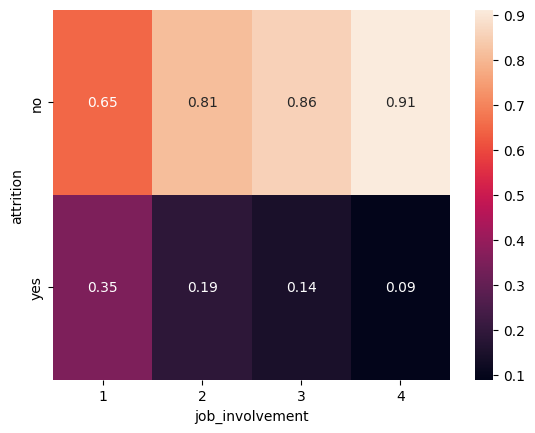

In [ ]:
sns.heatmap(tabla, annot=True);